In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

OUT_DIR = "outs/seer"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 123
np.random.seed(42)

seer_data = pd.read_excel("seer_final.xlsx")
print("原始数据维度:", seer_data.shape)

data = seer_data.copy()

data["T_major"] = data["T_major"].astype(str).str.strip()

data = data[
    data["T_major"].isin(["T1", "T2", "T3", "T4"])
].copy()

data["tumor_size_cm"] = pd.to_numeric(
    data["tumor_size_cm"],
    errors="coerce"
)

data = data[
    data["tumor_size_cm"].notna() &
    (data["tumor_size_cm"] < 14)
].copy()

data["N_major"] = data["N_major"].astype(str).str.strip()
data["M_major"] = data["M_major"].astype(str).str.strip()

data["Metastasis"] = np.where(
    (data["N_major"] != "N0") | (data["M_major"] != "M0"),
    1,
    0
)

data["Histology_group"] = data["Histology_group"].astype(str).str.strip()

histology_map = {
    "Adenocarcinoma": "Adenocarcinoma",
    "Mucinous adenocarcinoma": "Mucinous adenocarcinoma",
    "Signet ring cell carcinoma": "Signet ring cell carcinoma"
}

data["Histology_3group"] = data["Histology_group"].map(histology_map)

data = data[
    data["Histology_3group"].notna()
].copy()

site_col = "Site rec ICD-O-3/WHO 2008 (individual sites only)"

data[site_col] = data[site_col].astype(str).str.strip()

proximal_sites = [
    "Cecum",
    "Ascending Colon",
    "Hepatic Flexure",
    "Transverse Colon"
]

distal_sites = [
    "Splenic Flexure",
    "Descending Colon",
    "Sigmoid Colon"
]

rectal_sites = [
    "Rectosigmoid Junction",
    "Rectum"
]


def classify_site(site):
    if site in proximal_sites:
        return "Proximal colon"
    elif site in distal_sites:
        return "Distal colon"
    elif site in rectal_sites:
        return "Rectum"
    else:
        return np.nan


data["Location_3group"] = data[site_col].apply(classify_site)

data = data[
    data["Location_3group"].notna()
].copy()

diff_map = {
    "poor": 1,
    "moderate": 2,
    "well": 3
}

data["Differentiation_ord"] = (
    data["Differentiation_3group"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(diff_map)
)

pni_map = {
    "Negative": 0,
    "Positive": 1
}

data["PNI_binary"] = (
    data["PNI"]
    .astype(str)
    .str.strip()
    .map(pni_map)
)

sex_map = {
    "Female": 0,
    "Male": 1
}

data["Sex_binary"] = (
    data["Sex"]
    .astype(str)
    .str.strip()
    .map(sex_map)
)

analysis_data = data[
    [
        "Sex_binary",
        "Age",
        "tumor_size_cm",
        "T_major",              # 仅用于筛选，后续不进入模型
        "Metastasis",
        "PNI_binary",
        "Histology_3group",
        "Differentiation_ord",
        "Location_3group"
    ]
].copy()

analysis_data = analysis_data.loc[
    (analysis_data["T_major"] == "T4") &
    (analysis_data["Age"] < 50)
].copy()

analysis_data = analysis_data.drop(columns=["T_major"])

analysis_data["Age"] = pd.to_numeric(
    analysis_data["Age"],
    errors="coerce"
)

analysis_data["Metastasis"] = pd.to_numeric(
    analysis_data["Metastasis"],
    errors="coerce"
)

analysis_data = analysis_data.dropna(
    subset=[
        "Metastasis",
        "Sex_binary",
        "Age",
        "tumor_size_cm",
        "PNI_binary",
        "Differentiation_ord",
        "Histology_3group",
        "Location_3group"
    ]
).copy()

analysis_data["Metastasis"] = analysis_data["Metastasis"].astype(int)
analysis_data["Sex_binary"] = analysis_data["Sex_binary"].astype(int)
analysis_data["PNI_binary"] = analysis_data["PNI_binary"].astype(int)
analysis_data["Differentiation_ord"] = analysis_data["Differentiation_ord"].astype(int)

analysis_data.to_csv(
    os.path.join(OUT_DIR, "analysis_data_for_xgb.csv"),
    index=False,
    encoding="utf-8-sig"
)

X = analysis_data.drop(columns=["Metastasis"])
y = analysis_data["Metastasis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = [
    "Sex_binary",
    "Age",
    "tumor_size_cm",
    "PNI_binary",
    "Differentiation_ord"
]

categorical_features = [
    "Histology_3group",
    "Location_3group"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_imp = preprocessor.fit_transform(X_train)
X_test_imp = preprocessor.transform(X_test)

cat_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

feature_names = numeric_features + cat_feature_names

X_train_imp = pd.DataFrame(
    X_train_imp,
    columns=feature_names,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    X_test_imp,
    columns=feature_names,
    index=X_test.index
)

X_train_imp.to_csv(
    os.path.join(OUT_DIR, "X_train_preprocessed.csv"),
    index=True,
    encoding="utf-8-sig"
)

X_test_imp.to_csv(
    os.path.join(OUT_DIR, "X_test_preprocessed.csv"),
    index=True,
    encoding="utf-8-sig"
)

y_train.to_csv(
    os.path.join(OUT_DIR, "y_train.csv"),
    index=True,
    encoding="utf-8-sig"
)

y_test.to_csv(
    os.path.join(OUT_DIR, "y_test.csv"),
    index=True,
    encoding="utf-8-sig"
)

neg_n = (y_train == 0).sum()
pos_n = (y_train == 1).sum()
scale_pos_weight = neg_n / pos_n


xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train_imp, y_train)

原始数据维度: (205538, 13)


,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



AUC: 0.693
Accuracy: 0.638
Precision: 0.884
Recall / Sensitivity: 0.628
Specificity: 0.676
F1: 0.735

Classification report:
              precision    recall  f1-score   support

           0       0.32      0.68      0.43       179
           1       0.88      0.63      0.73       705

    accuracy                           0.64       884
   macro avg       0.60      0.65      0.58       884
weighted avg       0.77      0.64      0.67       884


Confusion matrix:
[[121  58]
 [262 443]]


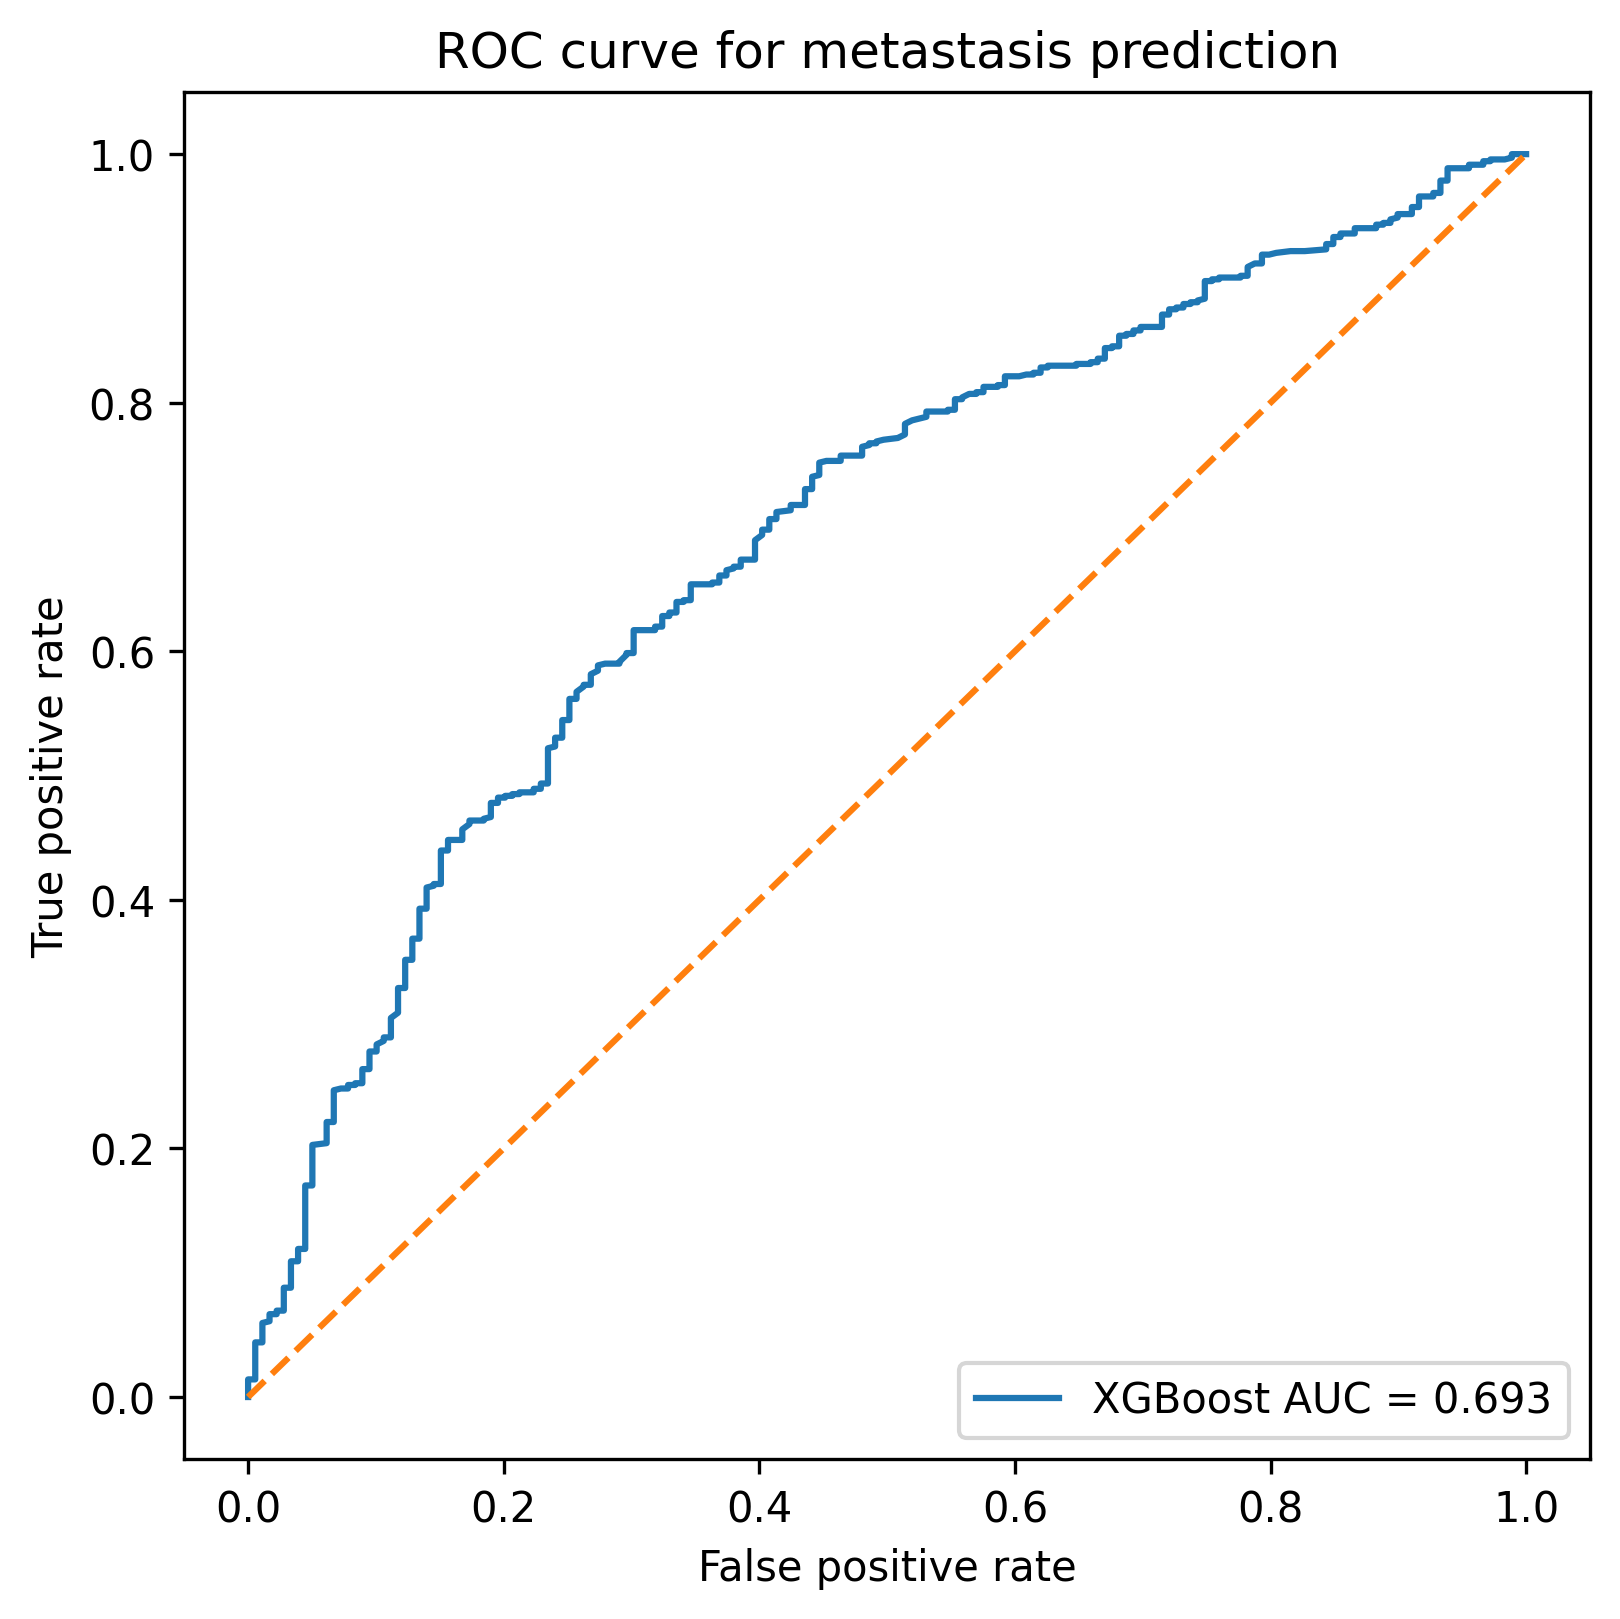

In [4]:
y_prob = xgb_model.predict_proba(X_test_imp)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
sensitivity = recall

print("\nAUC:", round(auc, 3))
print("Accuracy:", round(acc, 3))
print("Precision:", round(precision, 3))
print("Recall / Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("F1:", round(f1, 3))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion matrix:")
print(cm)

metrics_df = pd.DataFrame({
    "Metric": [
        "AUC",
        "Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP"
    ],
    "Value": [
        auc,
        acc,
        precision,
        sensitivity,
        specificity,
        f1,
        tn,
        fp,
        fn,
        tp
    ]
})

metrics_df.to_csv(
    os.path.join(OUT_DIR, "xgb_metastasis_metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)

prediction_df = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_prob,
    "y_pred": y_pred
}, index=y_test.index)

prediction_df.to_csv(
    os.path.join(OUT_DIR, "xgb_test_predictions.csv"),
    index=True,
    encoding="utf-8-sig"
)

cm_df = pd.DataFrame(
    cm,
    index=["True 0", "True 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_df.to_csv(
    os.path.join(OUT_DIR, "xgb_confusion_matrix.csv"),
    index=True,
    encoding="utf-8-sig"
)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_df = pd.DataFrame({
    "threshold": thresholds,
    "FPR": fpr,
    "TPR": tpr
})

roc_df.to_csv(
    os.path.join(OUT_DIR, "xgb_roc_curve_data.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(5.5, 5.5), dpi=300)
plt.plot(fpr, tpr, label=f"XGBoost AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve for metastasis prediction")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "xgb_metastasis_ROC.pdf"),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_DIR, "xgb_metastasis_ROC.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

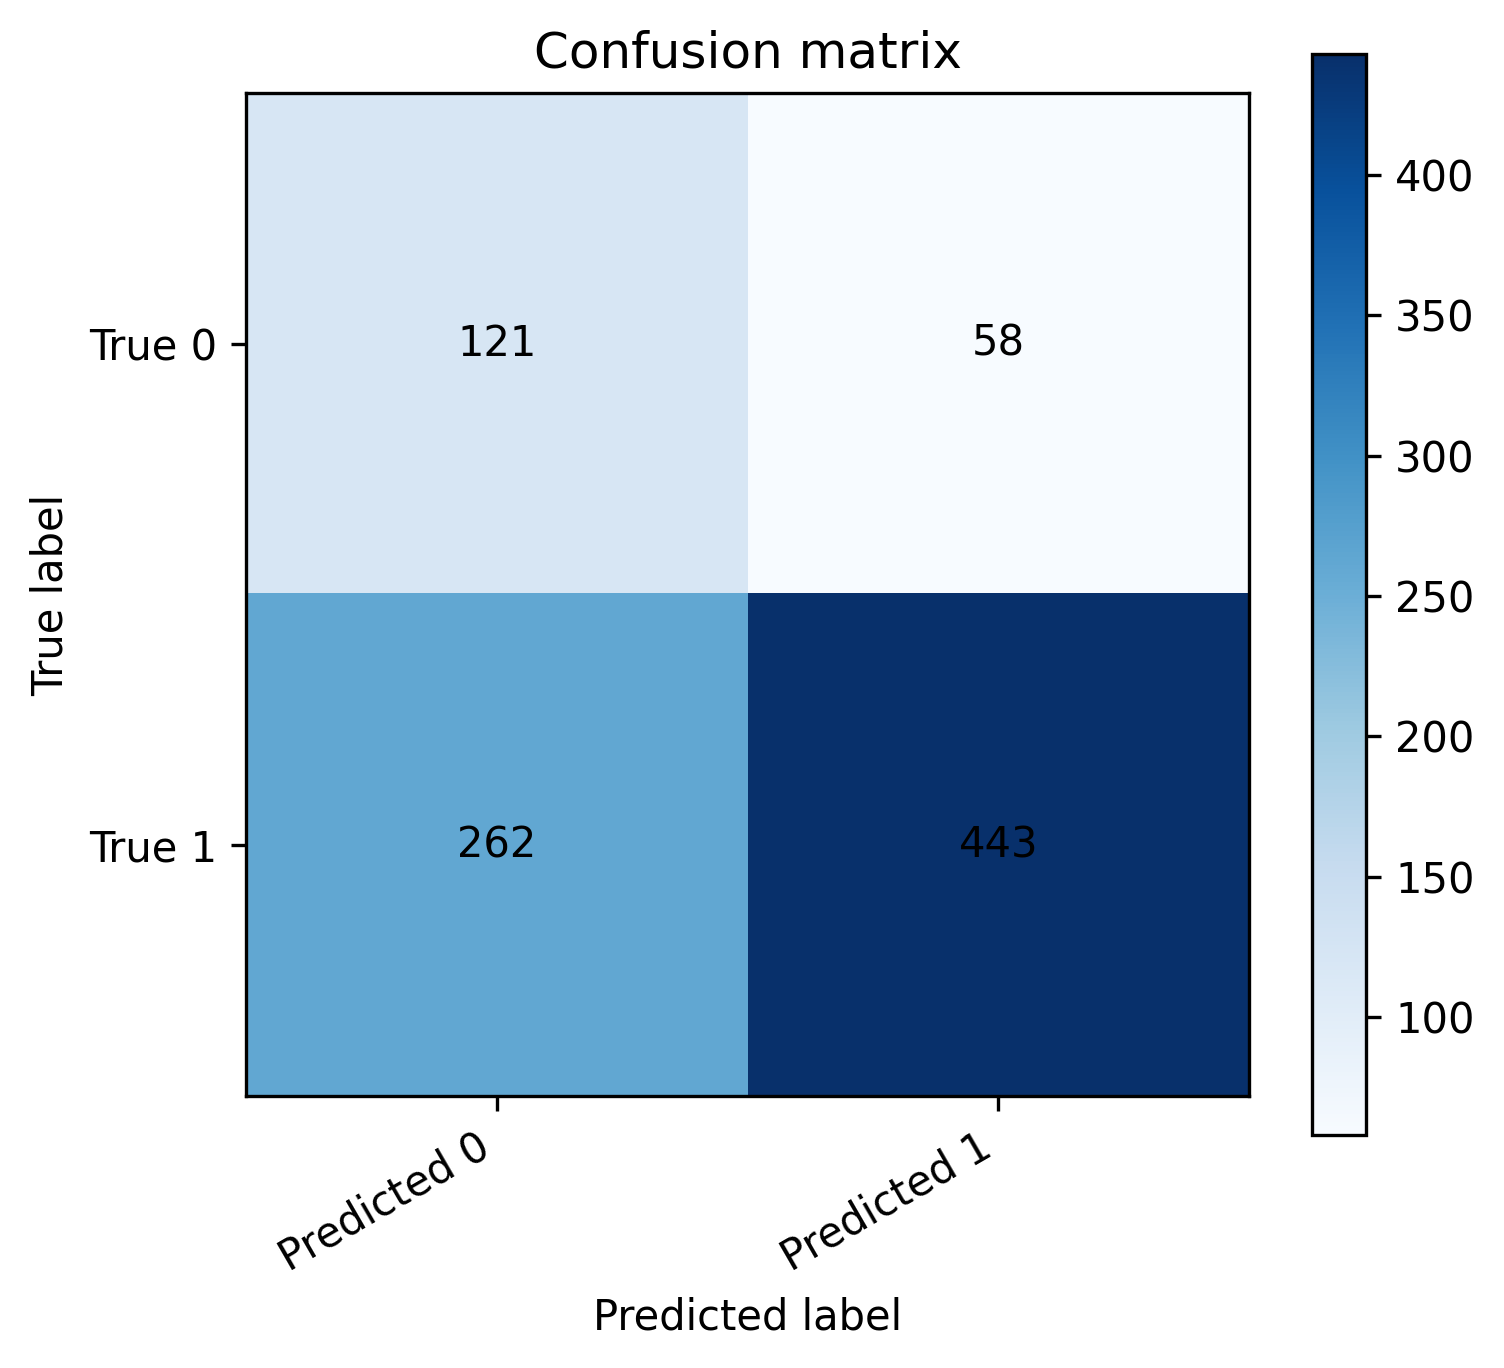


Top 30 XGBoost feature importance:
                                        Feature  Importance
3                                    PNI_binary    0.443265
4                           Differentiation_ord    0.095680
7   Histology_3group_Signet ring cell carcinoma    0.074576
2                                 tumor_size_cm    0.068582
10                       Location_3group_Rectum    0.066009
5               Histology_3group_Adenocarcinoma    0.055114
9                Location_3group_Proximal colon    0.049487
1                                           Age    0.039867
0                                    Sex_binary    0.037573
8                  Location_3group_Distal colon    0.035535
6      Histology_3group_Mucinous adenocarcinoma    0.034313


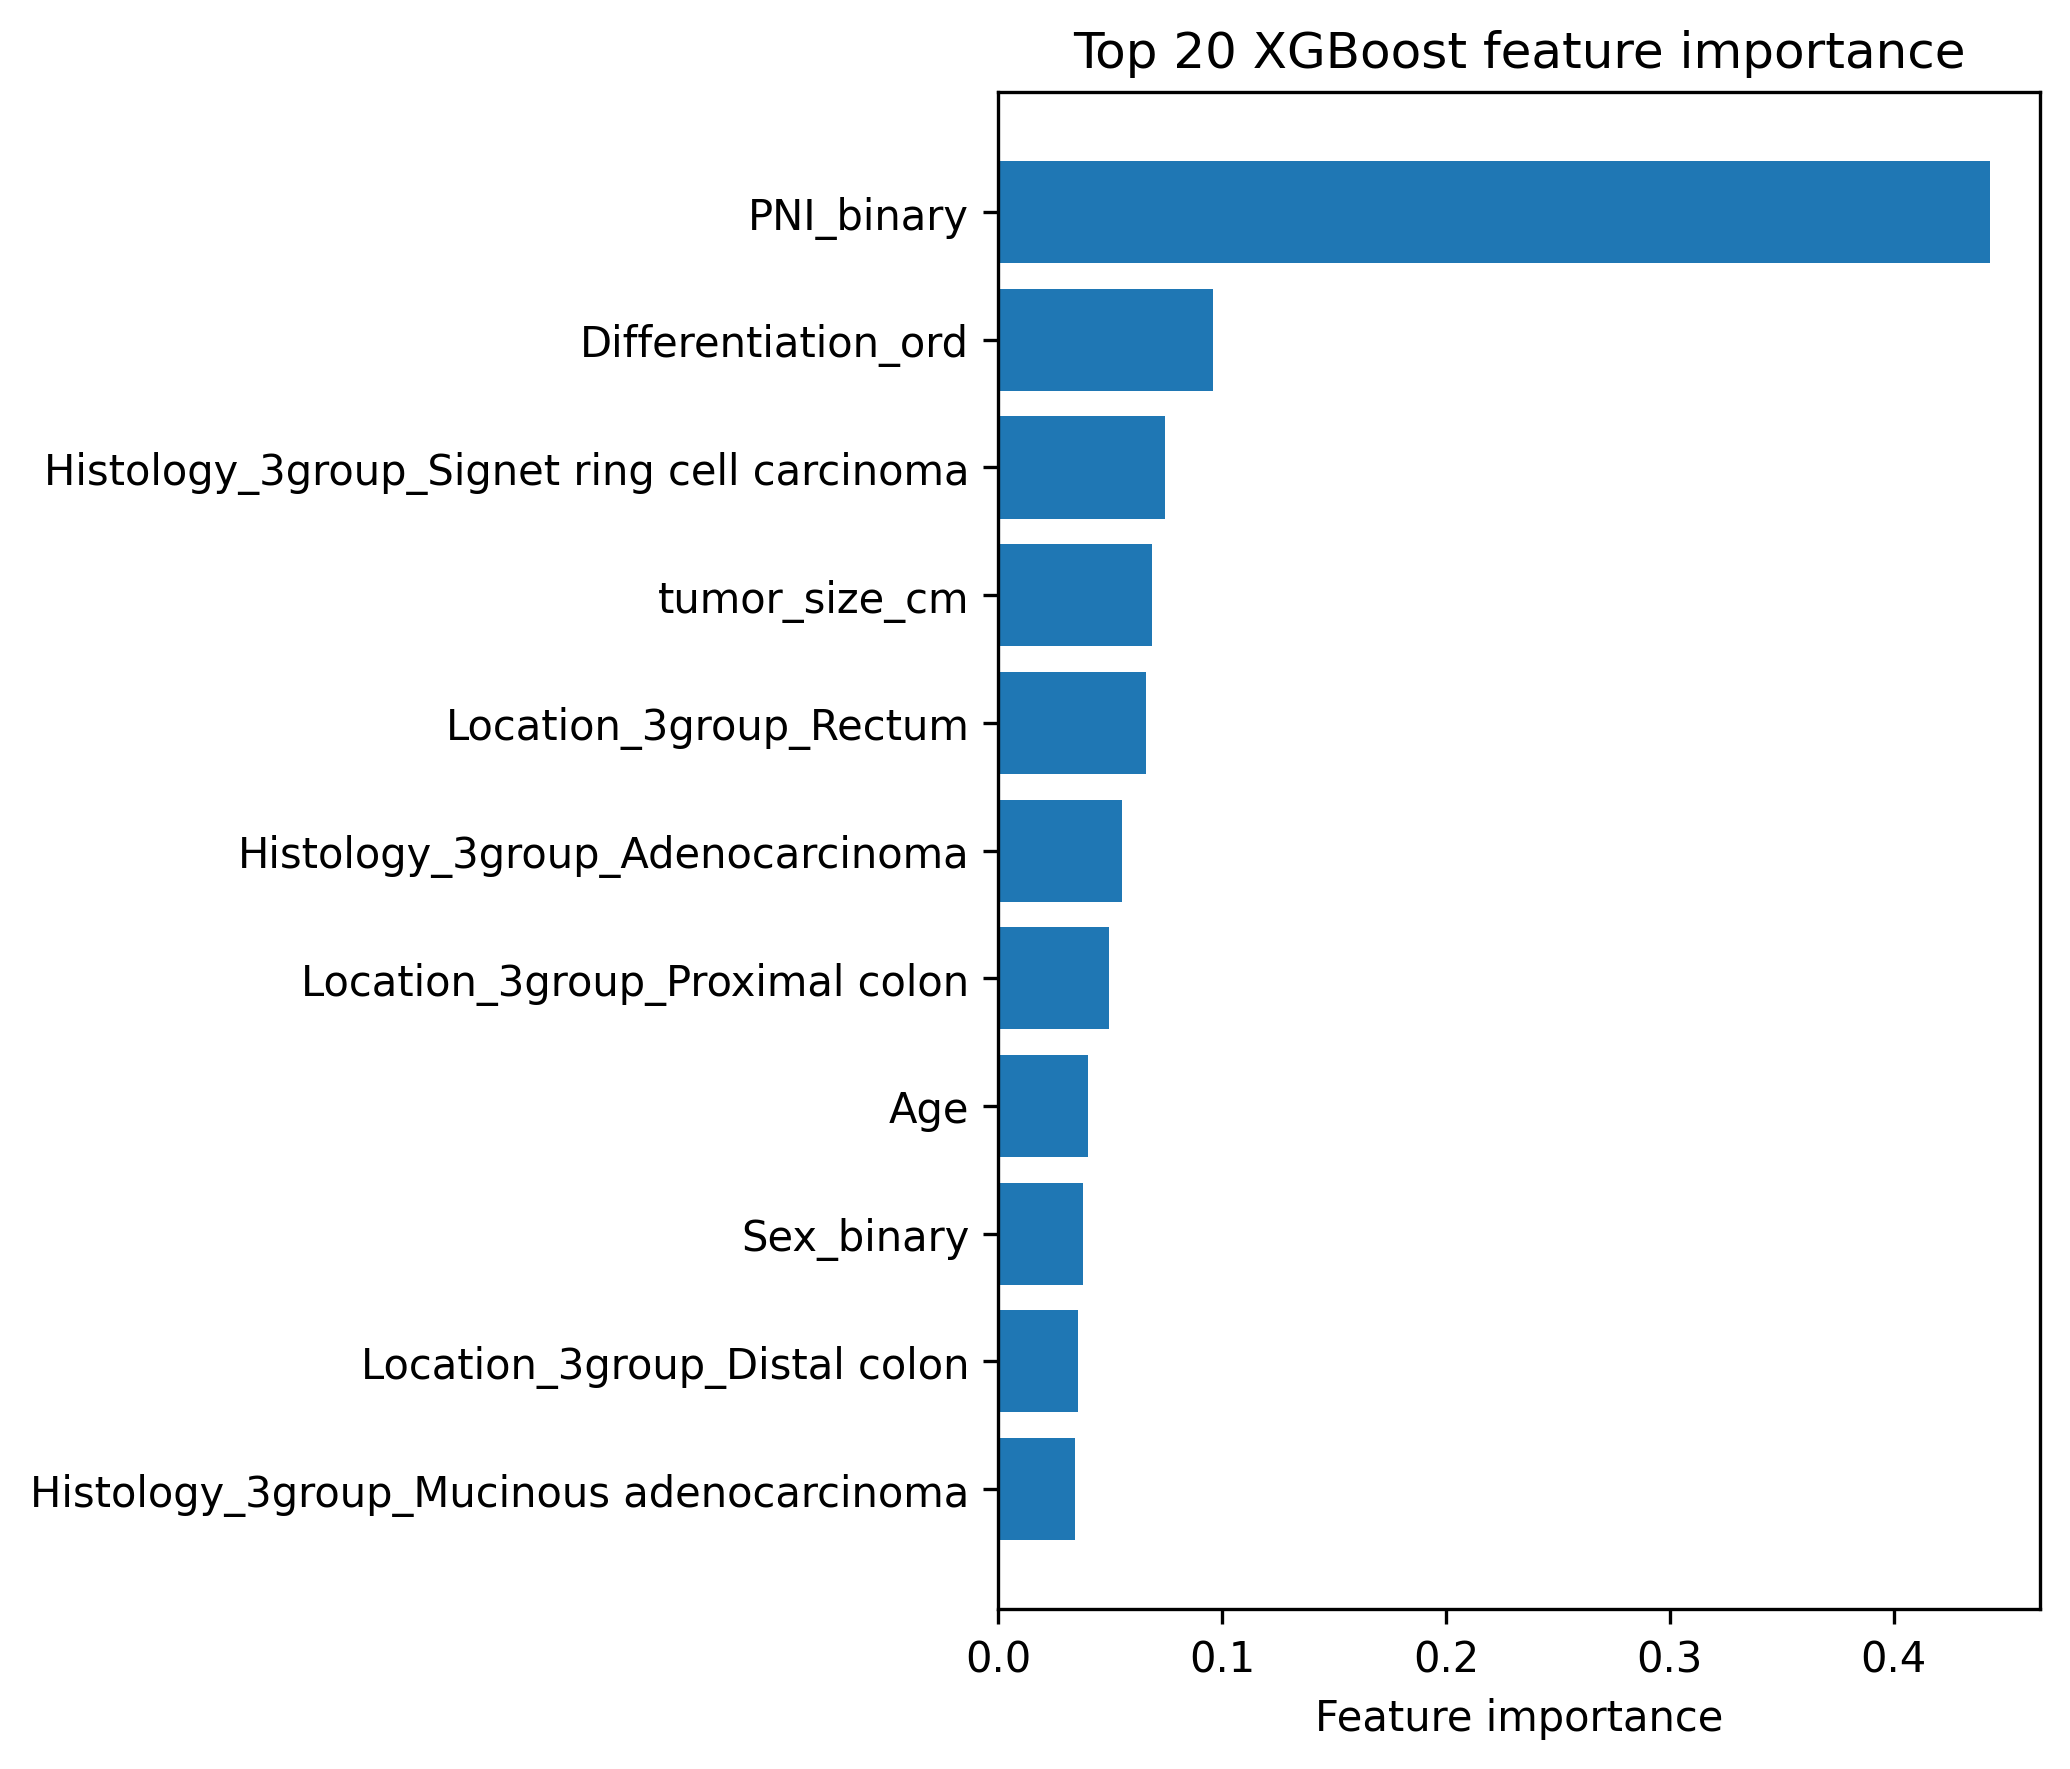

In [5]:
plt.figure(figsize=(5.2, 4.6), dpi=300)

plt.imshow(cm, interpolation="nearest",cmap = 'Blues')
plt.title("Confusion matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Predicted 0", "Predicted 1"], rotation=30, ha="right")
plt.yticks(tick_marks, ["True 0", "True 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "xgb_confusion_matrix.pdf"),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_DIR, "xgb_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()



importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 30 XGBoost feature importance:")
print(importance_df.head(30))

importance_df.to_csv(
    os.path.join(OUT_DIR, "xgb_feature_importance.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(7, 6), dpi=300)

top_imp = importance_df.head(20).iloc[::-1]

plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.xlabel("Feature importance")
plt.title("Top 20 XGBoost feature importance")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "xgb_feature_importance_top20.pdf"),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_DIR, "xgb_feature_importance_top20.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


SHAP values shape: (3533, 11)


/var/folders/pf/mltwcq3x44s2c4y7yy_rxccm0000gn/T/ipykernel_2020/2242939829.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


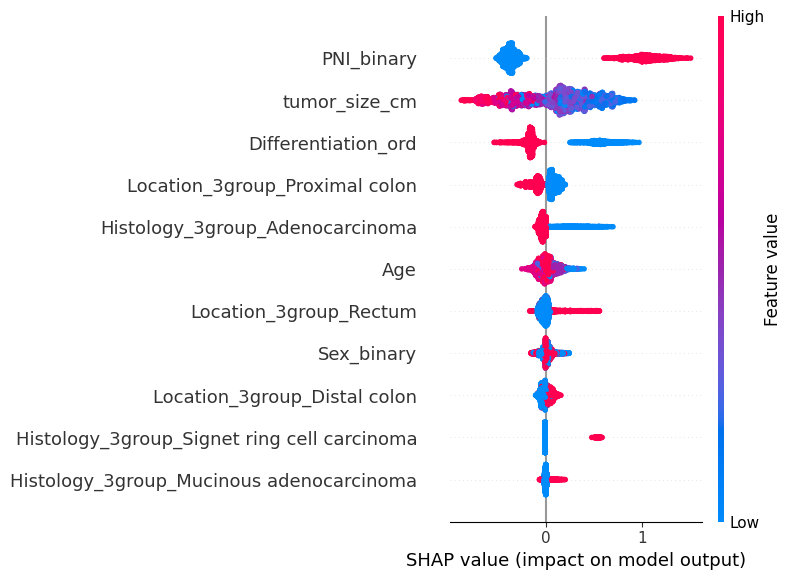


Top 30 SHAP feature importance:
                                        Feature  mean_abs_SHAP
3                                    PNI_binary       0.613570
2                                 tumor_size_cm       0.341638
4                           Differentiation_ord       0.285423
9                Location_3group_Proximal colon       0.093630
5               Histology_3group_Adenocarcinoma       0.073390
1                                           Age       0.068465
10                       Location_3group_Rectum       0.054796
0                                    Sex_binary       0.041609
8                  Location_3group_Distal colon       0.038610
7   Histology_3group_Signet ring cell carcinoma       0.024311
6      Histology_3group_Mucinous adenocarcinoma       0.012021


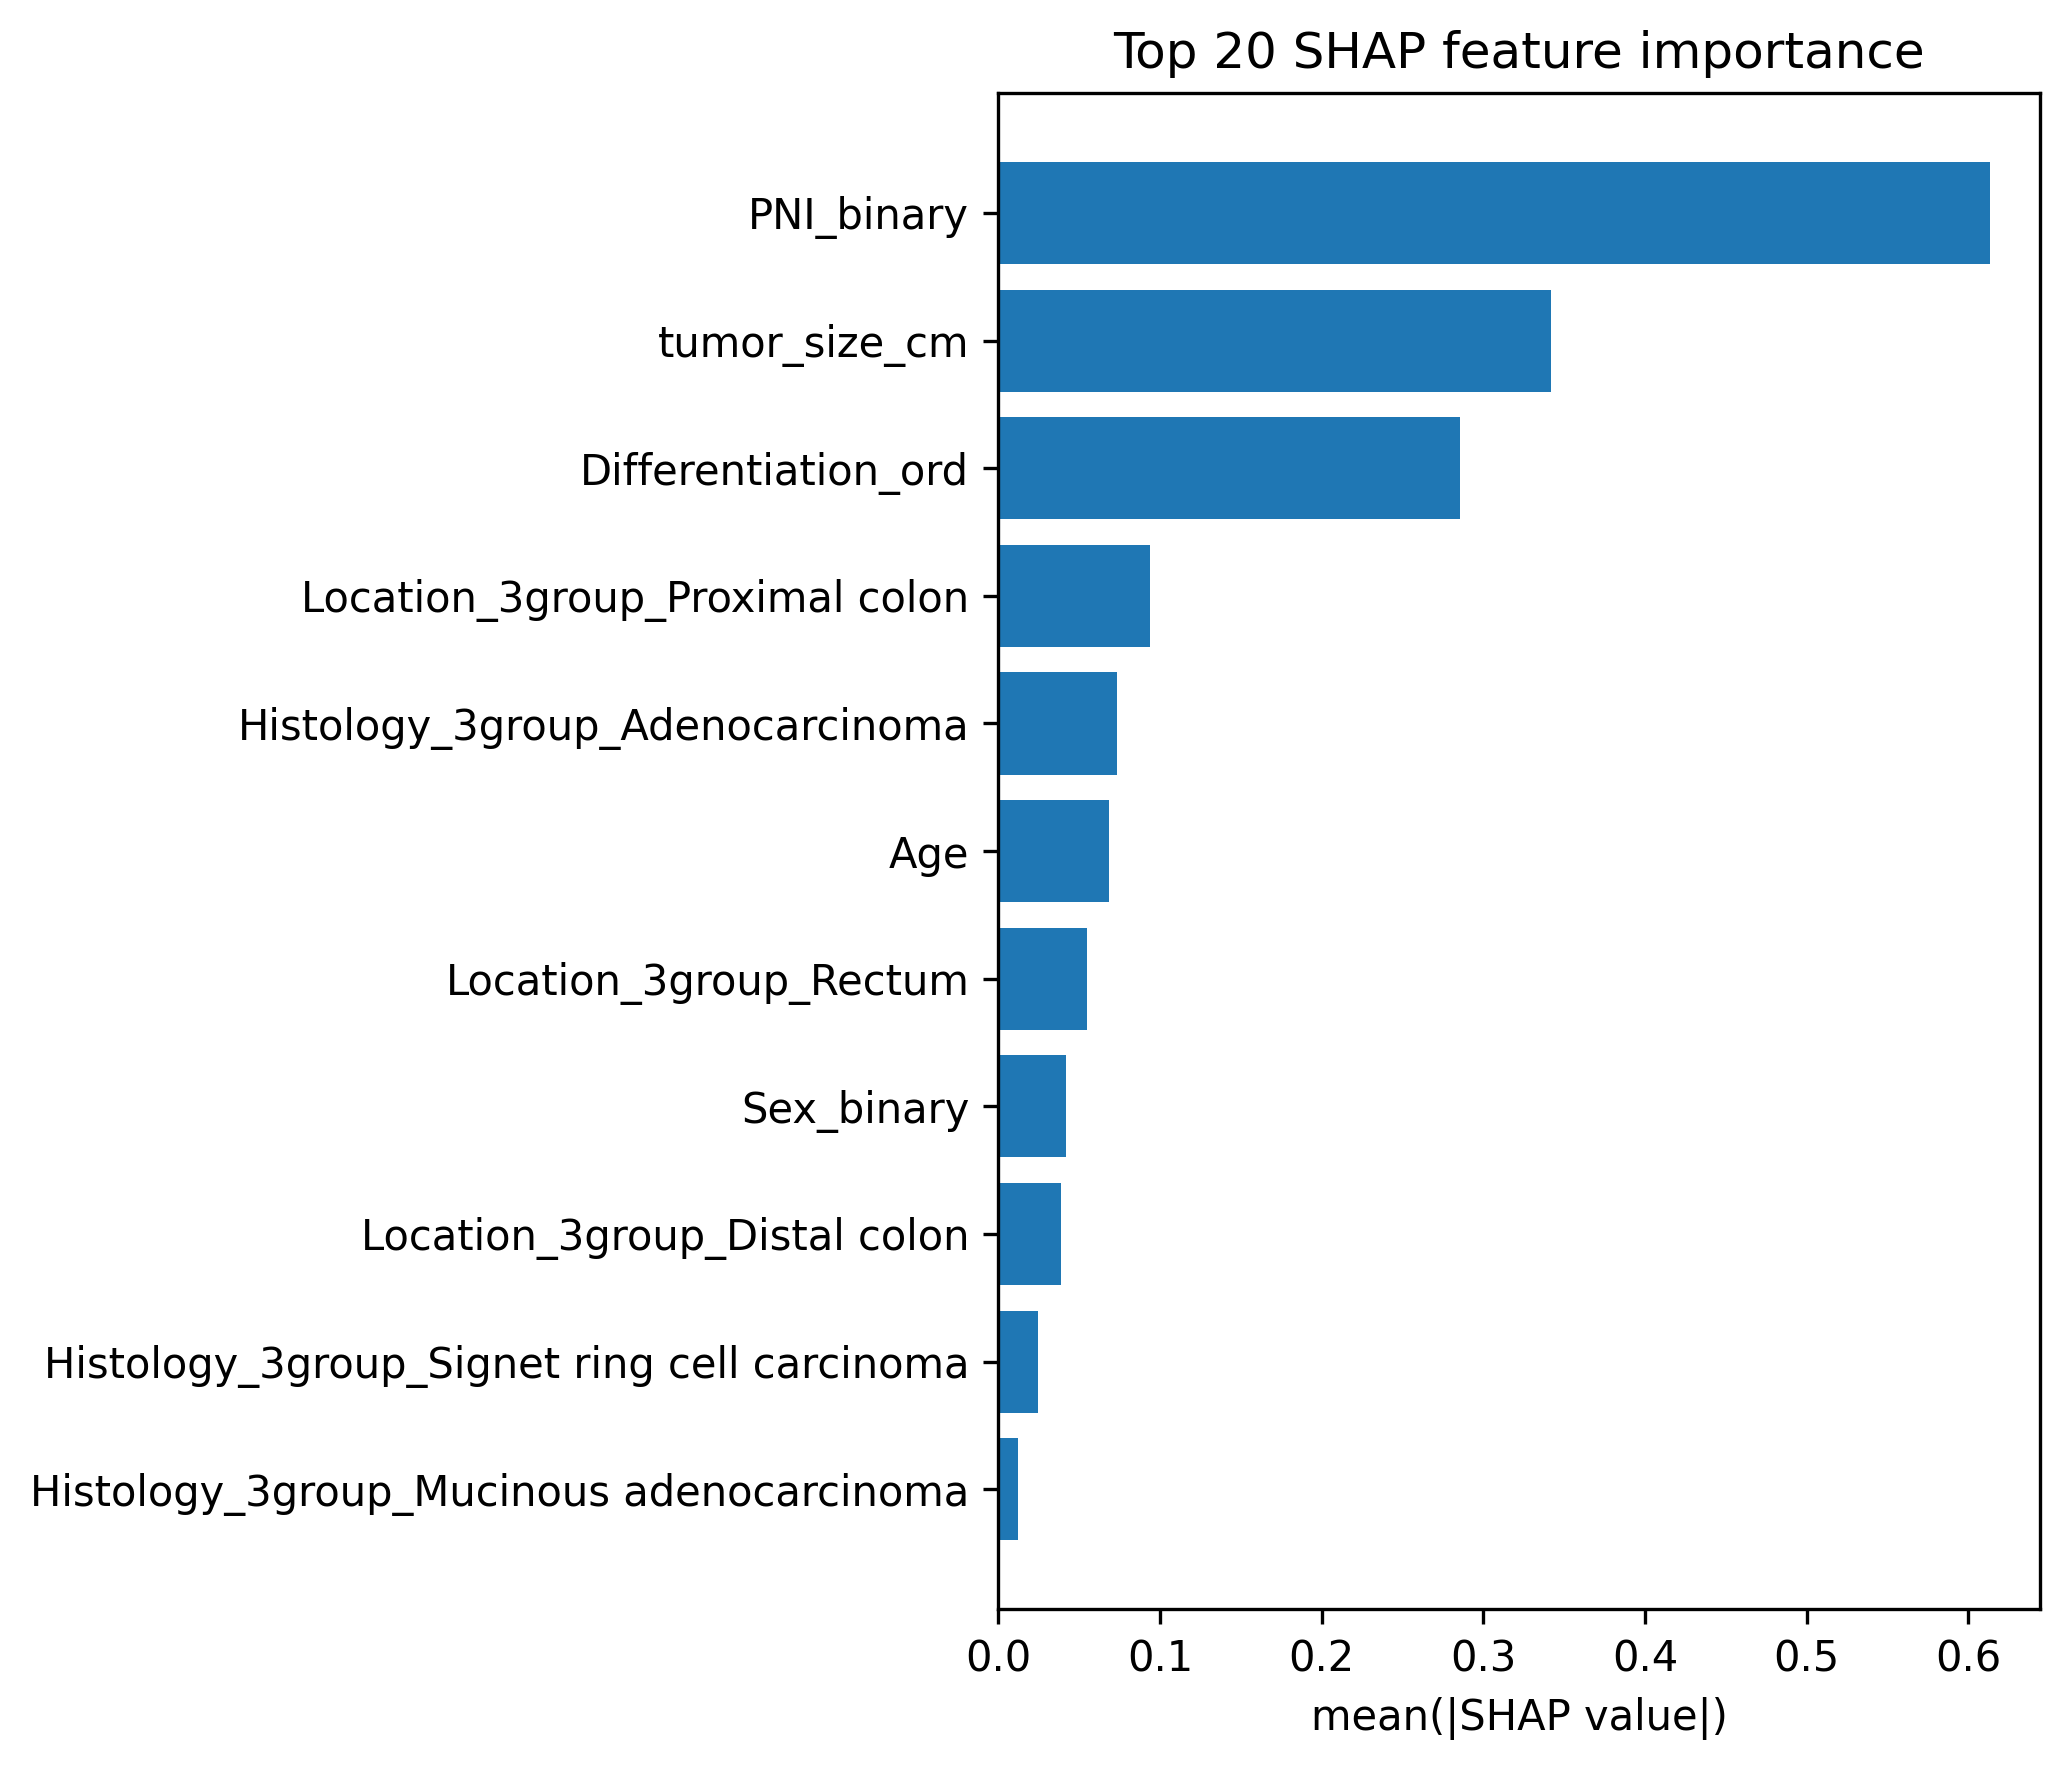

In [6]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_imp)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("\nSHAP values shape:", shap_values.shape)


plt.figure()

shap.summary_plot(
    shap_values,
    X_train_imp,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.pdf"),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "mean_abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_SHAP", ascending=False)

print("\nTop 30 SHAP feature importance:")
print(shap_importance.head(30))

shap_importance.to_csv(
    os.path.join(OUT_DIR, "shap_mean_abs_importance.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(7, 6), dpi=300)

top_shap = shap_importance.head(20).iloc[::-1]

plt.barh(top_shap["Feature"], top_shap["mean_abs_SHAP"])
plt.xlabel("mean(|SHAP value|)")
plt.title("Top 20 SHAP feature importance")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "shap_mean_abs_importance_top20.pdf"),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUT_DIR, "shap_mean_abs_importance_top20.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
